# Pairs Trading Strategy — US Financial Sector (2016–2025)

This project implements a statistical arbitrage (pairs trading) strategy 
on six large-cap US bank stocks: JPM, GS, MS, C, BAC, and WFC.

The strategy identifies cointegrated pairs using correlation analysis, 
OLS regression, and the Augmented Dickey-Fuller test. Trading signals 
are generated using a z-score of the spread, with rolling 6-month 
re-estimation to avoid look-ahead bias.

**Key findings:**
- Best cointegrated pair: Citigroup (C) & Bank of America (BAC), p-value = 0.0012
- Half-life of mean reversion: 6.4 trading days
- Optimal threshold z* = 1.5, generating 95.36% cumulative return (2017–2025)
- Sharpe ratio: 0.4664 | Max drawdown: -37.28%


---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv('AI_project_financials.csv', header=None) 
print(df_raw.shape)
print(df_raw.head())

(2516, 17)
           0             1   2           3             4   5           6   \
0         JPM           NaN NaN          GS           NaN NaN          MS   
1       Date:  Stock Price: NaN       Date:  Stock Price: NaN       Date:   
2  01/04/2016         63.62 NaN  01/04/2016        177.14 NaN  01/04/2016   
3  01/05/2016         63.73 NaN  01/05/2016        174.09 NaN  01/05/2016   
4  01/06/2016         62.81 NaN  01/06/2016        169.84 NaN  01/06/2016   

             7   8           9             10  11          12            13  \
0           NaN NaN           C           NaN NaN         BAC           NaN   
1  Stock Price: NaN       Date:  Stock Price: NaN       Date:  Stock Price:   
2         31.48 NaN  01/04/2016         51.13 NaN  01/04/2016         16.43   
3         31.28 NaN  01/05/2016         50.86 NaN  01/05/2016         16.43   
4          30.5 NaN  01/06/2016         50.12 NaN  01/06/2016         16.08   

   14          15            16  
0 NaN         WFC

## 1. Data Loading & Cleaning
Daily close prices for 6 US bank stocks pulled from Bloomberg Terminal (2016–2025).

In [3]:
df = pd.DataFrame()

tickers = ['JPM', 'GS', 'MS', 'C', 'BAC', 'WFC']
col_pairs = [(0,1), (3,4), (6,7), (9,10), (12,13), (15,16)]

for ticker, (date_col, price_col) in zip(tickers, col_pairs):
    temp = df_raw[[date_col, price_col]].copy()
    temp.columns = ['Date', ticker]
    temp = temp.iloc[2:].reset_index(drop=True) 
    temp['Date'] = pd.to_datetime(temp['Date'])
    temp[ticker] = pd.to_numeric(temp[ticker])
    if df.empty:
        df = temp
    else:
        df = df.merge(temp, on='Date')

df = df.sort_values('Date').reset_index(drop=True)
print(df.shape)
print(df.head())

(2514, 7)
        Date    JPM      GS     MS      C    BAC    WFC
0 2016-01-04  63.62  177.14  31.48  51.13  16.43  52.91
1 2016-01-05  63.73  174.09  31.28  50.86  16.43  52.89
2 2016-01-06  62.81  169.84  30.50  50.12  16.08  51.88
3 2016-01-07  60.27  164.62  28.98  47.56  15.50  50.40
4 2016-01-08  58.92  163.94  28.38  46.13  15.20  49.56


In [4]:
# Compute log daily returns for all 6 tickers
log_returns = np.log(df[tickers] / df[tickers].shift(1))
log_returns = log_returns.dropna()
log_returns['Date'] = df['Date'][log_returns.index]
print(log_returns.shape)
print(log_returns.head())

(2513, 7)
        JPM        GS        MS         C       BAC       WFC       Date
1  0.001728 -0.017368 -0.006374 -0.005295  0.000000 -0.000378 2016-01-05
2 -0.014541 -0.024716 -0.025252 -0.014657 -0.021533 -0.019281 2016-01-06
3 -0.041280 -0.031217 -0.051121 -0.052428 -0.036736 -0.028942 2016-01-07
4 -0.022654 -0.004139 -0.020921 -0.030529 -0.019545 -0.016807 2016-01-08
5 -0.001529  0.010859  0.002815  0.015488  0.007211  0.010637 2016-01-11


## 2. Log Returns & Correlation Matrix
Computing daily log returns and identifying highly correlated pairs as candidates for cointegration testing.

In [5]:
# In-sample data: 2016 only
insample = log_returns[log_returns['Date'].dt.year == 2016]

# Correlation matrix
corr_matrix = insample[tickers].corr()
print(corr_matrix.round(4))

        JPM      GS      MS       C     BAC     WFC
JPM  1.0000  0.8691  0.8778  0.9141  0.8935  0.8210
GS   0.8691  1.0000  0.9025  0.8743  0.8658  0.7982
MS   0.8778  0.9025  1.0000  0.9054  0.8796  0.7801
C    0.9141  0.8743  0.9054  1.0000  0.9249  0.7981
BAC  0.8935  0.8658  0.8796  0.9249  1.0000  0.7975
WFC  0.8210  0.7982  0.7801  0.7981  0.7975  1.0000


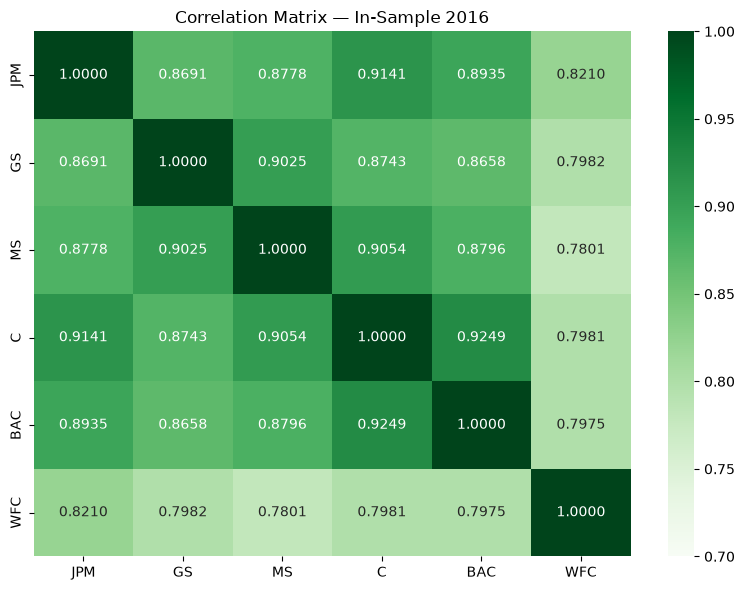

In [6]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='Greens',
            vmin=0.7, vmax=1.0)
plt.title('Correlation Matrix — In-Sample 2016')
plt.tight_layout()
plt.show()

## 3. Pair Selection — OLS Regression & ADF Test
Running 15 OLS regressions to estimate hedge ratios, then testing each spread for stationarity using the Augmented Dickey-Fuller test.

In [7]:
from itertools import combinations
import statsmodels.api as sm

# In-sample price data (2016 only)
insample_prices = df[df['Date'].dt.year == 2016][['Date'] + tickers].reset_index(drop=True)

# Run OLS regression for all 15 pairs
print("=" * 55)
print("OLS REGRESSIONS — In-Sample 2016")
print("=" * 55)

ols_results = {}

for stock_i, stock_j in combinations(tickers, 2):
    log_pi = np.log(insample_prices[stock_i])
    log_pj = np.log(insample_prices[stock_j])
    
    X = sm.add_constant(log_pj)
    model = sm.OLS(log_pi, X).fit()
    
    alpha = model.params['const']
    beta = model.params.iloc[1]
    r2 = model.rsquared
    
    ols_results[(stock_i, stock_j)] = {'alpha': alpha, 'beta': beta, 'r2': r2}
    
    print(f"{stock_i} ~ {stock_j}:")
    print(f"   Alpha: {alpha:.4f} | Beta: {beta:.4f} | R²: {r2:.4f}")

OLS REGRESSIONS — In-Sample 2016
JPM ~ GS:
   Alpha: 0.1351 | Beta: 0.7894 | R²: 0.8930
JPM ~ MS:
   Alpha: 2.0862 | Beta: 0.6187 | R²: 0.9279
JPM ~ C:
   Alpha: 0.5980 | Beta: 0.9345 | R²: 0.9243
JPM ~ BAC:
   Alpha: 2.3735 | Beta: 0.6626 | R²: 0.9316
JPM ~ WFC:
   Alpha: -0.2964 | Beta: 1.1503 | R²: 0.3335
GS ~ MS:
   Alpha: 2.6597 | Beta: 0.7281 | R²: 0.8969
GS ~ C:
   Alpha: 0.9031 | Beta: 1.1012 | R²: 0.8956
GS ~ BAC:
   Alpha: 2.9359 | Beta: 0.8026 | R²: 0.9538
GS ~ WFC:
   Alpha: -1.3293 | Beta: 1.6585 | R²: 0.4838
MS ~ C:
   Alpha: -2.2058 | Beta: 1.4584 | R²: 0.9285
MS ~ BAC:
   Alpha: 0.5314 | Beta: 1.0464 | R²: 0.9583
MS ~ WFC:
   Alpha: -2.8050 | Beta: 1.5903 | R²: 0.2630
C ~ BAC:
   Alpha: 1.9377 | Beta: 0.6952 | R²: 0.9688
C ~ WFC:
   Alpha: -1.0029 | Beta: 1.2427 | R²: 0.3678
BAC ~ WFC:
   Alpha: -4.3164 | Beta: 1.8098 | R²: 0.3891


In [8]:
from statsmodels.tsa.stattools import adfuller

print("=" * 55)
print("ADF TEST P-VALUES — In-Sample 2016")
print("=" * 55)

adf_results = {}

for stock_i, stock_j in combinations(tickers, 2):
    alpha = ols_results[(stock_i, stock_j)]['alpha']
    beta = ols_results[(stock_i, stock_j)]['beta']
    
    log_pi = np.log(insample_prices[stock_i])
    log_pj = np.log(insample_prices[stock_j])
    
    spread = log_pi - beta * log_pj
    
    adf_pvalue = adfuller(spread, autolag='AIC')[1]
    adf_results[(stock_i, stock_j)] = adf_pvalue
    
    stationary = "✓ stationary" if adf_pvalue < 0.05 else "✗ not stationary"
    print(f"{stock_i}-{stock_j}: p-value = {adf_pvalue:.4f}  {stationary}")

# Find best pair
best_pair = min(adf_results, key=adf_results.get)
print("\n" + "=" * 55)
print(f"BEST PAIR: {best_pair[0]} & {best_pair[1]} | p-value = {adf_results[best_pair]:.4f}")
print("=" * 55)

ADF TEST P-VALUES — In-Sample 2016
JPM-GS: p-value = 0.1456  ✗ not stationary
JPM-MS: p-value = 0.2086  ✗ not stationary
JPM-C: p-value = 0.0014  ✓ stationary
JPM-BAC: p-value = 0.0864  ✗ not stationary
JPM-WFC: p-value = 0.8664  ✗ not stationary
GS-MS: p-value = 0.7964  ✗ not stationary
GS-C: p-value = 0.3438  ✗ not stationary
GS-BAC: p-value = 0.2996  ✗ not stationary
GS-WFC: p-value = 0.8089  ✗ not stationary
MS-C: p-value = 0.0711  ✗ not stationary
MS-BAC: p-value = 0.1873  ✗ not stationary
MS-WFC: p-value = 0.9067  ✗ not stationary
C-BAC: p-value = 0.0012  ✓ stationary
C-WFC: p-value = 0.7677  ✗ not stationary
BAC-WFC: p-value = 0.8075  ✗ not stationary

BEST PAIR: C & BAC | p-value = 0.0012


In [9]:
# Selected pair
stock_i = 'C'
stock_j = 'BAC'

beta_insample = ols_results[(stock_i, stock_j)]['beta']
alpha_insample = ols_results[(stock_i, stock_j)]['alpha']

# Construct in-sample spread
log_pi = np.log(insample_prices[stock_i])
log_pj = np.log(insample_prices[stock_j])
spread_insample = log_pi - beta_insample * log_pj

mu = spread_insample.mean()
sigma = spread_insample.std()

print("=" * 40)
print(f"MU & SIGMA FOR {stock_i}-{stock_j}")
print("=" * 40)
print(f"Hedge ratio β : {beta_insample:.6f}")
print(f"Mean μ        : {mu:.6f}")
print(f"Std dev σ     : {sigma:.6f}")

MU & SIGMA FOR C-BAC
Hedge ratio β : 0.695160
Mean μ        : 1.937708
Std dev σ     : 0.020264


In [10]:
# Half-life of mean reversion (Ornstein-Uhlenbeck)
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Construct in-sample spread
log_pi_is = np.log(insample_prices[stock_i])
log_pj_is = np.log(insample_prices[stock_j])
spread_is = log_pi_is - beta_insample * log_pj_is

# Regress spread(t) on spread(t-1)
spread_lagged = spread_is.shift(1).dropna()
spread_diff = spread_is.diff().dropna()

X = add_constant(spread_lagged)
ou_model = OLS(spread_diff, X).fit()

# Half-life = -log(2) / lambda
lambda_ou = ou_model.params.iloc[1]
half_life = -np.log(2) / lambda_ou

print("=" * 40)
print(f"HALF-LIFE OF MEAN REVERSION: {stock_i}-{stock_j}")
print("=" * 40)
print(f"Lambda (λ)  : {lambda_ou:.6f}")
print(f"Half-life   : {half_life:.1f} trading days")
print(f"             (~{half_life/21:.1f} months)")
print("=" * 40)

if half_life < 0:
    print("WARNING: positive lambda means spread is not mean-reverting")
elif half_life < 5:
    print("Very fast reversion — good for high frequency")
elif half_life < 30:
    print("Fast reversion — good for short-term trading")
elif half_life < 60:
    print("Moderate reversion — suitable for this strategy")
else:
    print("Slow reversion — trades may take months to close")

HALF-LIFE OF MEAN REVERSION: C-BAC
Lambda (λ)  : -0.108716
Half-life   : 6.4 trading days
             (~0.3 months)
Fast reversion — good for short-term trading


## 4. Rolling Re-estimation & Z-Score Construction
Re-estimating parameters every 6 months using a rolling 1-year window to avoid look-ahead bias.

In [11]:
# Rolling 6-month windows out-of-sample (2017-2025)
# 18 windows total: Jul2016-Jun2017, Jan2017-Dec2017... Jul2024-Jun2025

out_of_sample = df[df['Date'].dt.year >= 2017].reset_index(drop=True)

import pandas as pd
from dateutil.relativedelta import relativedelta

# Generate rolling window parameters
rolling_params = []

# First window uses in-sample 2016 parameters
window_start = pd.Timestamp('2016-01-01')

for i in range(18):
    window_end = window_start + relativedelta(months=12) - relativedelta(days=1)
    next_start = window_start + relativedelta(months=6)
    next_end = next_start + relativedelta(months=6) - relativedelta(days=1)
    
    # Get data for this window
    mask = (df['Date'] >= window_start) & (df['Date'] <= window_end)
    window_data = df[mask].reset_index(drop=True)
    
    if len(window_data) < 50:
        window_start = next_start
        continue
    
    log_pi = np.log(window_data[stock_i])
    log_pj = np.log(window_data[stock_j])
    
    X = sm.add_constant(log_pj)
    model = sm.OLS(log_pi, X).fit()
    
    b = model.params.iloc[1]
    spread = log_pi - b * log_pj
    m = spread.mean()
    s = spread.std()
    
    rolling_params.append({
        'window_start': window_start,
        'window_end': window_end,
        'apply_start': next_start,
        'apply_end': next_end,
        'beta': b,
        'mu': m,
        'sigma': s
    })
    
    window_start = next_start

print(f"Total rolling windows: {len(rolling_params)}")
print("\nFirst 3 windows:")
for p in rolling_params[:3]:
    print(f"  Train: {p['window_start'].date()} to {p['window_end'].date()} → Apply: {p['apply_start'].date()} to {p['apply_end'].date()}")
    print(f"  β={p['beta']:.4f} | μ={p['mu']:.4f} | σ={p['sigma']:.4f}")

Total rolling windows: 18

First 3 windows:
  Train: 2016-01-01 to 2016-12-31 → Apply: 2016-07-01 to 2016-12-31
  β=0.6952 | μ=1.9377 | σ=0.0203
  Train: 2016-07-01 to 2017-06-30 → Apply: 2017-01-01 to 2017-06-30
  β=0.6069 | μ=2.1843 | σ=0.0276
  Train: 2017-01-01 to 2017-12-31 → Apply: 2017-07-01 to 2017-12-31
  β=1.0150 | μ=0.9279 | σ=0.0534


In [12]:
# Construct out-of-sample spread and z-score using rolling parameters
spread_list = []

for params in rolling_params:
    mask = (df['Date'] >= params['apply_start']) & (df['Date'] <= params['apply_end'])
    period_data = df[mask].copy()
    
    if len(period_data) == 0:
        continue
    
    log_pi = np.log(period_data[stock_i])
    log_pj = np.log(period_data[stock_j])
    
    period_data['spread'] = log_pi - params['beta'] * log_pj
    period_data['zscore'] = (period_data['spread'] - params['mu']) / params['sigma']
    period_data['beta'] = params['beta']
    period_data['mu'] = params['mu']
    period_data['sigma'] = params['sigma']
    
    spread_list.append(period_data)

spread_df = pd.concat(spread_list).reset_index(drop=True)

# Keep only out-of-sample (2017 onwards)
spread_df = spread_df[spread_df['Date'].dt.year >= 2017].reset_index(drop=True)

print(f"Out-of-sample rows: {len(spread_df)}")
print(spread_df[['Date', 'spread', 'zscore']].head(10))

Out-of-sample rows: 2134
        Date    spread    zscore
0 2017-01-03  2.213865  1.068820
1 2017-01-04  2.216099  1.149627
2 2017-01-05  2.205703  0.773616
3 2017-01-06  2.209177  0.899280
4 2017-01-09  2.207201  0.827790
5 2017-01-10  2.196961  0.457417
6 2017-01-11  2.189039  0.170870
7 2017-01-12  2.180748 -0.129011
8 2017-01-13  2.185100  0.028414
9 2017-01-17  2.189777  0.197564


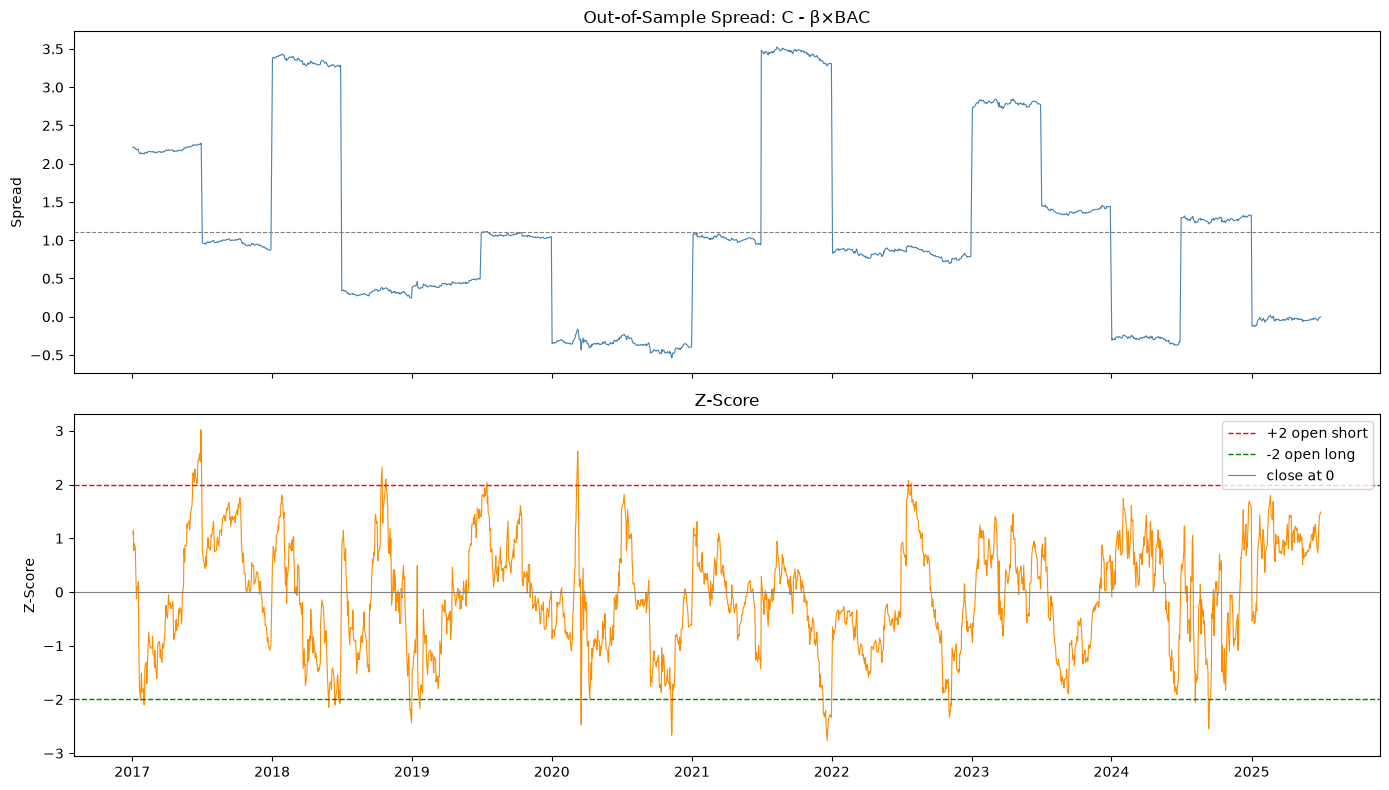

Z-score range: -2.77 to 3.02


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Spread plot
ax1.plot(spread_df['Date'], spread_df['spread'], color='steelblue', linewidth=0.8)
ax1.set_title(f'Out-of-Sample Spread: {stock_i} - β×{stock_j}')
ax1.set_ylabel('Spread')
ax1.axhline(y=spread_df['spread'].mean(), color='gray', linestyle='--', linewidth=0.8)

# Z-score plot
ax2.plot(spread_df['Date'], spread_df['zscore'], color='darkorange', linewidth=0.8)
ax2.axhline(y=2, color='red', linestyle='--', linewidth=1, label='+2 open short')
ax2.axhline(y=-2, color='green', linestyle='--', linewidth=1, label='-2 open long')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, label='close at 0')
ax2.set_title('Z-Score')
ax2.set_ylabel('Z-Score')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Z-score range: {spread_df['zscore'].min():.2f} to {spread_df['zscore'].max():.2f}")

## 5. Backtest & Performance Analysis
Simulating the pairs trading strategy out-of-sample (2017–2025) with z* = 1.5, including threshold sensitivity analysis and transaction cost impact.

In [14]:
# Backtest: correct dollar-based pairs trading PnL
portfolio = 100.0
z_star = 1.5

position = 0
entry_date = None
entry_zscore = None
entry_portfolio = None
entry_price_i = None  # C price at entry
entry_price_j = None  # BAC price at entry
entry_beta = None
shares_i = None
shares_j = None

trades = []
portfolio_values = []

for i, row in spread_df.iterrows():
    z = row['zscore']
    date = row['Date']
    price_i = df.loc[df['Date'] == date, stock_i].values[0]
    price_j = df.loc[df['Date'] == date, stock_j].values[0]
    beta = row['beta']

    # Close position
    if position == 1 and z >= 0:
        pnl = shares_i * (price_i - entry_price_i) + shares_j * (entry_price_j - price_j)
        portfolio = entry_portfolio + pnl
        trades.append({
            'Entry Date': entry_date, 'Exit Date': date,
            'Direction': 'Long', 'Entry Z': round(entry_zscore, 3),
            'Exit Z': round(z, 3), 'Portfolio $': round(portfolio, 2)
        })
        position = 0

    elif position == -1 and z <= 0:
        pnl = shares_i * (entry_price_i - price_i) + shares_j * (price_j - entry_price_j)
        portfolio = entry_portfolio + pnl
        trades.append({
            'Entry Date': entry_date, 'Exit Date': date,
            'Direction': 'Short', 'Entry Z': round(entry_zscore, 3),
            'Exit Z': round(z, 3), 'Portfolio $': round(portfolio, 2)
        })
        position = 0

    # Open new position
    if position == 0:
        if z > z_star or z < -z_star:
            # Allocate capital: split by hedge ratio
            # Long i, short j (or vice versa) scaled to portfolio
            total = portfolio
            dollars_i = total / (1 + beta)
            dollars_j = total - dollars_i

            if z > z_star:
                position = -1  # short spread: short i, long j
                shares_i = -dollars_i / price_i
                shares_j = dollars_j / price_j
            else:
                position = 1   # long spread: long i, short j
                shares_i = dollars_i / price_i
                shares_j = -dollars_j / price_j

            entry_date = date
            entry_zscore = z
            entry_portfolio = portfolio
            entry_price_i = price_i
            entry_price_j = price_j
            entry_beta = beta

    portfolio_values.append({'Date': date, 'Portfolio': portfolio})

# Force close at end
if position != 0:
    last = spread_df.iloc[-1]
    date = last['Date']
    price_i = df.loc[df['Date'] == date, stock_i].values[0]
    price_j = df.loc[df['Date'] == date, stock_j].values[0]
    if position == 1:
        pnl = shares_i * (price_i - entry_price_i) + shares_j * (entry_price_j - price_j)
    else:
        pnl = shares_i * (entry_price_i - price_i) + shares_j * (price_j - entry_price_j)
    portfolio = entry_portfolio + pnl
    trades.append({
        'Entry Date': entry_date, 'Exit Date': date,
        'Direction': 'Long' if position == 1 else 'Short',
        'Entry Z': round(entry_zscore, 3),
        'Exit Z': round(last['zscore'], 3),
        'Portfolio $': round(portfolio, 2)
    })

portfolio_df = pd.DataFrame(portfolio_values)
trades_df = pd.DataFrame(trades)

# Performance metrics
returns = portfolio_df['Portfolio'].pct_change().dropna()
sharpe = returns.mean() / returns.std() * np.sqrt(252)
rolling_max = portfolio_df['Portfolio'].cummax()
drawdown = (portfolio_df['Portfolio'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()
cumulative_return = (portfolio_df['Portfolio'].iloc[-1] - 100) / 100

print("=" * 45)
print("BACKTEST RESULTS — NO TRANSACTION COSTS")
print("=" * 45)
print(f"Cumulative Return : {cumulative_return*100:.2f}%")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Max Drawdown      : {max_drawdown*100:.2f}%")
print(f"Number of Trades  : {len(trades_df)}")
print("\nTRADE LOG:")
print(trades_df.to_string(index=True))

BACKTEST RESULTS — NO TRANSACTION COSTS
Cumulative Return : 95.36%
Sharpe Ratio      : 0.4664
Max Drawdown      : -37.28%
Number of Trades  : 25

TRADE LOG:
   Entry Date  Exit Date Direction  Entry Z  Exit Z  Portfolio $
0  2017-01-20 2017-05-15      Long   -1.817   0.119       108.26
1  2017-06-05 2017-10-27     Short    1.578  -0.008       131.97
2  2018-01-24 2018-02-08     Short    1.642  -0.217       120.01
3  2018-03-29 2018-07-02      Long   -1.740   0.804       118.07
4  2018-08-10 2018-09-18      Long   -1.516   0.269       116.93
5  2018-10-12 2018-11-09     Short    1.885  -0.245       113.90
6  2018-12-21 2019-01-15      Long   -1.564   0.491       133.92
7  2019-01-17 2019-04-16      Long   -1.783   0.201       143.02
8  2019-06-21 2019-10-29     Short    1.563  -0.022       158.70
9  2020-03-05 2020-03-17     Short    1.615  -1.988       117.53
10 2020-03-17 2020-03-23      Long   -1.988   0.448        99.53
11 2020-04-07 2020-06-23      Long   -1.711   0.144       118.4

In [15]:
# Threshold sensitivity table
z_stars = [1.5, 2.0, 2.5, 3.0]
results_sensitivity = []

for zs in z_stars:
    port = 100.0
    pos = 0
    e_date = None
    e_zscore = None
    e_port = None
    e_price_i = None
    e_price_j = None
    e_beta = None
    s_i = None
    s_j = None
    trade_count = 0
    port_vals = []

    for i, row in spread_df.iterrows():
        z = row['zscore']
        date = row['Date']
        price_i = df.loc[df['Date'] == date, stock_i].values[0]
        price_j = df.loc[df['Date'] == date, stock_j].values[0]
        beta = row['beta']

        if pos == 1 and z >= 0:
            pnl = s_i * (price_i - e_price_i) + s_j * (e_price_j - price_j)
            port = e_port + pnl
            pos = 0
            trade_count += 1

        elif pos == -1 and z <= 0:
            pnl = s_i * (e_price_i - price_i) + s_j * (price_j - e_price_j)
            port = e_port + pnl
            pos = 0
            trade_count += 1

        if pos == 0:
            if z > zs or z < -zs:
                total = port
                dollars_i = total / (1 + beta)
                dollars_j = total - dollars_i
                if z > zs:
                    pos = -1
                    s_i = -dollars_i / price_i
                    s_j = dollars_j / price_j
                else:
                    pos = 1
                    s_i = dollars_i / price_i
                    s_j = -dollars_j / price_j
                e_date = date
                e_zscore = z
                e_port = port
                e_price_i = price_i
                e_price_j = price_j
                e_beta = beta

        port_vals.append(port)

    # Force close
    if pos != 0:
        last = spread_df.iloc[-1]
        date = last['Date']
        price_i = df.loc[df['Date'] == date, stock_i].values[0]
        price_j = df.loc[df['Date'] == date, stock_j].values[0]
        if pos == 1:
            pnl = s_i * (price_i - e_price_i) + s_j * (e_price_j - price_j)
        else:
            pnl = s_i * (e_price_i - price_i) + s_j * (price_j - e_price_j)
        port = e_port + pnl
        trade_count += 1
        port_vals[-1] = port

    port_series = pd.Series(port_vals)
    rets = port_series.pct_change().dropna()
    sharpe = rets.mean() / rets.std() * np.sqrt(252)
    roll_max = port_series.cummax()
    dd = ((port_series - roll_max) / roll_max).min()
    cum_ret = (port_series.iloc[-1] - 100) / 100

    results_sensitivity.append({
        'z*': zs,
        'Trades': trade_count,
        'Cumulative Return': f"{cum_ret*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.4f}",
        'Max Drawdown': f"{dd*100:.2f}%"
    })

sensitivity_df = pd.DataFrame(results_sensitivity)
print("=" * 65)
print("THRESHOLD SENSITIVITY TABLE")
print("=" * 65)
print(sensitivity_df.to_string(index=False))

THRESHOLD SENSITIVITY TABLE
 z*  Trades Cumulative Return Sharpe Ratio Max Drawdown
1.5      25            96.71%       0.4700      -37.28%
2.0      15            26.07%       0.2689      -32.77%
2.5       5            -2.13%       0.0364      -22.46%
3.0       1            11.81%       0.3437        0.00%


In [16]:
# Backtest with 0.05% transaction cost per trade
tc = 0.0005

portfolio_tc = 100.0
position = 0
entry_date = None
entry_zscore = None
entry_portfolio_tc = None
entry_price_i = None
entry_price_j = None
shares_i = None
shares_j = None

portfolio_values_tc = []

for i, row in spread_df.iterrows():
    z = row['zscore']
    date = row['Date']
    price_i = df.loc[df['Date'] == date, stock_i].values[0]
    price_j = df.loc[df['Date'] == date, stock_j].values[0]
    beta = row['beta']

    if position == 1 and z >= 0:
        pnl = shares_i * (price_i - entry_price_i) + shares_j * (entry_price_j - price_j)
        portfolio_tc = entry_portfolio_tc + pnl
        portfolio_tc *= (1 - tc)
        position = 0

    elif position == -1 and z <= 0:
        pnl = shares_i * (entry_price_i - price_i) + shares_j * (price_j - entry_price_j)
        portfolio_tc = entry_portfolio_tc + pnl
        portfolio_tc *= (1 - tc)
        position = 0

    if position == 0:
        if z > z_star or z < -z_star:
            total = portfolio_tc * (1 - tc)
            dollars_i = total / (1 + beta)
            dollars_j = total - dollars_i
            if z > z_star:
                position = -1
                shares_i = -dollars_i / price_i
                shares_j = dollars_j / price_j
            else:
                position = 1
                shares_i = dollars_i / price_i
                shares_j = -dollars_j / price_j
            entry_date = date
            entry_zscore = z
            entry_portfolio_tc = portfolio_tc
            entry_price_i = price_i
            entry_price_j = price_j

    portfolio_values_tc.append({'Date': date, 'Portfolio': portfolio_tc})

portfolio_tc_df = pd.DataFrame(portfolio_values_tc)

returns_tc = portfolio_tc_df['Portfolio'].pct_change().dropna()
sharpe_tc = returns_tc.mean() / returns_tc.std() * np.sqrt(252)
rolling_max_tc = portfolio_tc_df['Portfolio'].cummax()
drawdown_tc = (portfolio_tc_df['Portfolio'] - rolling_max_tc) / rolling_max_tc
max_drawdown_tc = drawdown_tc.min()
cumulative_return_tc = (portfolio_tc_df['Portfolio'].iloc[-1] - 100) / 100

print("=" * 45)
print("BACKTEST — WITH 0.05% TRANSACTION COSTS")
print("=" * 45)
print(f"Cumulative Return : {cumulative_return_tc*100:.2f}%")
print(f"Sharpe Ratio      : {sharpe_tc:.4f}")
print(f"Max Drawdown      : {max_drawdown_tc*100:.2f}%")

BACKTEST — WITH 0.05% TRANSACTION COSTS
Cumulative Return : 92.99%
Sharpe Ratio      : 0.4606
Max Drawdown      : -37.33%


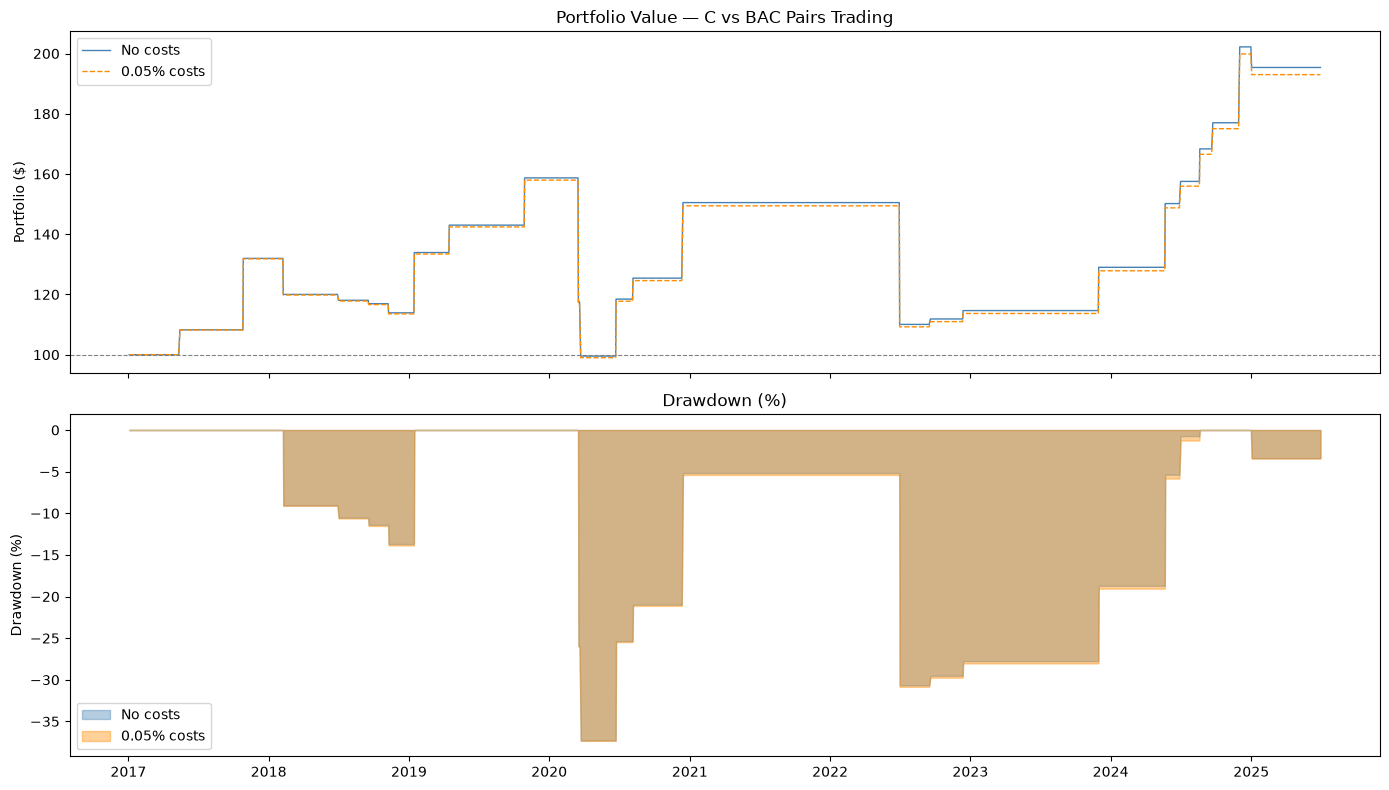

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Portfolio value
ax1.plot(portfolio_df['Date'], portfolio_df['Portfolio'], 
         color='steelblue', linewidth=1, label='No costs')
ax1.plot(portfolio_tc_df['Date'], portfolio_tc_df['Portfolio'], 
         color='darkorange', linewidth=1, linestyle='--', label='0.05% costs')
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
ax1.set_title('Portfolio Value — C vs BAC Pairs Trading')
ax1.set_ylabel('Portfolio ($)')
ax1.legend()

# Drawdown
rolling_max = portfolio_df['Portfolio'].cummax()
drawdown = (portfolio_df['Portfolio'] - rolling_max) / rolling_max * 100
rolling_max_tc = portfolio_tc_df['Portfolio'].cummax()
drawdown_tc = (portfolio_tc_df['Portfolio'] - rolling_max_tc) / rolling_max_tc * 100

ax2.fill_between(portfolio_df['Date'], drawdown, 0, 
                  alpha=0.4, color='steelblue', label='No costs')
ax2.fill_between(portfolio_tc_df['Date'], drawdown_tc, 0, 
                  alpha=0.4, color='darkorange', label='0.05% costs')
ax2.set_title('Drawdown (%)')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()

plt.tight_layout()
plt.show()